**Module 5**

---

**Problem 3**

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, accuracy_score
)
import warnings
warnings.filterwarnings('ignore')

import torch
# print(torch.__version__)
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

plt.rcParams.update({'font.size': 14, 'figure.figsize': (8, 6)})
RNG = np.random.default_rng(42)

# set torch seed for reproducibility
torch.manual_seed(42)

# use GPU if available (not required)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# -------------------------
# 1. Define transformations
# -------------------------
from torchvision import datasets, transforms
transform = transforms.Compose([
    transforms.ToTensor(),                     # convert image to tensor [0,1]
    transforms.Normalize((0.1307,), (0.3081,))
])

# -------------------------
# 2. Load datasets
# -------------------------
mnist_train = datasets.MNIST('./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST('./data', train=False, transform=transform) # download=True

# For PyTorch training:
# -------------------------
# 3. Create DataLoaders
# -------------------------
from torch.utils.data import DataLoader
train_loader = DataLoader(mnist_train, batch_size=128, shuffle=True)
test_loader = DataLoader(mnist_test, batch_size=1000, shuffle=False)

# -------------------------
# 4. Check data
# -------------------------
for images, labels in train_loader:
    print("Images shape:", images.shape)  # (128, 1, 28, 28) 28×28 pixel grayscale (1 channel) image
    print("Labels shape:", labels.shape)  # (128,)
    break

# For sklearn (logistic regression), flatten to numpy:
# -------------------------
# 5. Convert to flattened numpy arrays and normalize pixel values to 0-1
# -------------------------
# MNIST images are grayscale with pixel values from 0 to 255
X_train_np = mnist_train.data.numpy().reshape(-1, 28*28).astype(np.float32) / 255.0
y_train_np = mnist_train.targets.numpy()
X_test_np = mnist_test.data.numpy().reshape(-1, 28*28).astype(np.float32) / 255.0
y_test_np = mnist_test.targets.numpy()

Using device: cpu
Images shape: torch.Size([128, 1, 28, 28])
Labels shape: torch.Size([128])


Label: 0
Shape: torch.Size([1, 28, 28])
Min value: -0.4242129623889923
Max value: 2.808758497238159


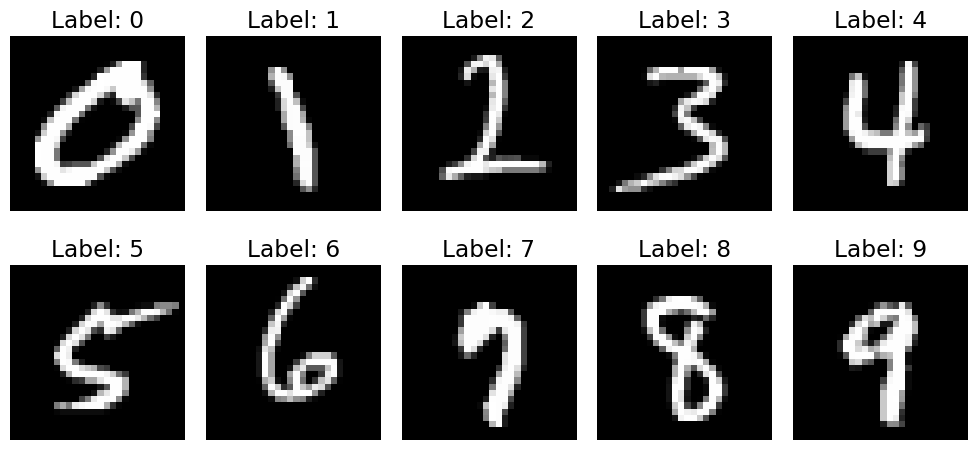

In [4]:
# Get one example per class (0–9)
examples = {}
for images, labels in train_loader:
    for img, label in zip(images, labels):
        label = label.item()
        if label not in examples:
            examples[label] = img  
        if len(examples) == 10:
            break
    if len(examples) == 10:
        break

i = 0
img = examples[i]
print("Label:", i)
print("Shape:", img.shape)
print("Min value:", img.min().item())
print("Max value:", img.max().item())
# print(img[0])

# Plot grid (2 rows x 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(10):
    ax = axes[i // 5, i % 5]
    img = examples[i].squeeze()  # squeeze removes size 1 dimensions (here channel dim = 1) (1,28,28) → (28,28)
    
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {i}")
    ax.axis('off')

plt.tight_layout()
plt.show()


Test Accuracy: 92.56%


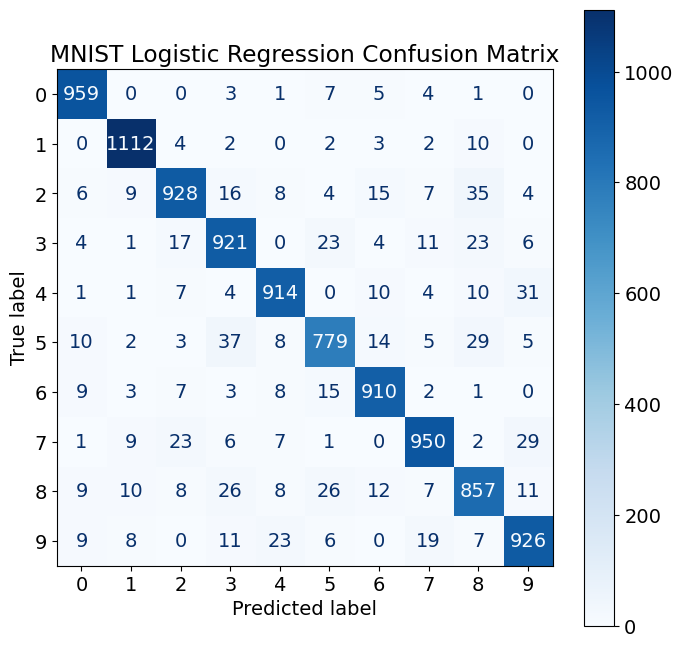

Most commonly confused digits: 5 -> 3 (count=37)


In [5]:
clf = LogisticRegression() # max_iter=1000, solver='lbfgs', multi_class='multinomial', n_jobs=-1
clf.fit(X_train_np, y_train_np)

y_pred = clf.predict(X_test_np)

acc = accuracy_score(y_test_np, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%")

# Confusion matrix
cm = confusion_matrix(y_test_np, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))

plt.figure(figsize=(8,8))
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title("MNIST Logistic Regression Confusion Matrix")
plt.show()

# 9. Identify most commonly confused digits
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)  # ignore correct predictions
max_confused = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)
print(f"Most commonly confused digits: {max_confused[0]} -> {max_confused[1]} (count={cm_no_diag[max_confused]})")


In [6]:
class FlexNet(nn.Module):
    """
    Flexible feedforward network.
    
    hidden_sizes: list of ints, e.g. [32, 16] for 2 hidden layers
    activation: 'sigmoid', 'relu', or 'tanh'
    """
    def __init__(self, input_dim, hidden_sizes, num_classes, activation='relu'):
        super().__init__()
        
        act_map = {'sigmoid': nn.Sigmoid, 'relu': nn.ReLU, 'tanh': nn.Tanh}
        act_fn = act_map[activation]
        
        layers = []
        prev_dim = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(act_fn())
            prev_dim = h
            
        layers.append(nn.Linear(prev_dim, num_classes)) # output layer for multi-class
        # layers.append(nn.Linear(prev_dim, 1))
        # No Sigmoid! CrossEntropyLoss expects raw logits
        # layers.append(nn.Sigmoid())  # output probability
        
        self.network = nn.Sequential(*layers)
    
    # def forward(self, x):
    #     return self.network(x).squeeze(-1)
    def forward(self, x):
        # Flatten input if needed
        x = x.view(x.size(0), -1)
        return self.network(x)  # raw logits

model = FlexNet(input_dim=28*28, hidden_sizes=[128], num_classes=10, activation='relu').to(device)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {n_params:,}")


FlexNet(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters: 101,770


In [7]:
def train_pytorch(model, train_loader, test_loader, lr=0.01, n_epochs=100, verbose=True):
    """
    Train a PyTorch model and track train/test loss.

    Arguments:
    - model: PyTorch nn.Module
    - train_loader: DataLoader for training set
    - test_loader: DataLoader for test set
    - lr: learning rate
    - n_epochs: number of epochs
    - verbose: print progress every 1 epoch
    """
    # Loss & optimizer
    criterion = nn.CrossEntropyLoss()  # combines softmax + log loss, works directly with raw logits
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    test_losses = []
    accuracies = []

    # Training loop
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        n_train_batches = 0
        
        for X_batch, y_batch in train_loader:
            # X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            # X_batch = X_batch.view(X_batch.size(0), -1)  # flatten input
            
            # forward
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            
            # backward (automatic!)
            optimizer.zero_grad()
            loss.backward()
            
            # update
            optimizer.step()
            
            epoch_loss += loss.item() # average loss in 1 batch, nn.CrossEntropyLoss by default returns mean over the batch
            n_train_batches += 1
        
        train_losses.append(epoch_loss / n_train_batches)

        
        # evaluate on test set
        model.eval()
        test_loss = 0.0
        acc = 0.0
        n_test_batches = 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                X_batch = X_batch.view(X_batch.size(0), -1)
                
                y_pred = model(X_batch)
                batch_size = X_batch.size(0)

                test_loss += criterion(y_pred, y_batch).item()

                # Accuracy for multi-class
                _, predicted = torch.max(y_pred, 1)
                acc += (predicted == y_batch).float().mean().item()

                n_test_batches += 1

            test_losses.append(test_loss / n_test_batches)
            accuracies.append(acc / n_test_batches)

        if verbose:
            print(f"  epoch {epoch:4d}  train_loss={train_losses[-1]:.4f}  "
                  f"test_loss={test_losses[-1]:.4f}  test_acc={accuracies[-1]:.2%}")
    
    return train_losses, test_losses

In [28]:
# Hyperparameters
input_size = 28*28
hidden_size = [128]
num_classes = 10
batch_size = 128
learning_rate = 0.01
num_epochs = 20

train_losses, test_losses = train_pytorch(
    model=model, 
    train_loader=train_loader, 
    test_loader=test_loader,
    lr=learning_rate,
    n_epochs=num_epochs
)


  epoch    0  train_loss=0.1463  test_loss=0.1757  test_acc=95.95%
  epoch    1  train_loss=0.1309  test_loss=0.1942  test_acc=95.97%
  epoch    2  train_loss=0.1249  test_loss=0.2079  test_acc=95.46%
  epoch    3  train_loss=0.1222  test_loss=0.2001  test_acc=96.28%
  epoch    4  train_loss=0.1190  test_loss=0.2029  test_acc=95.96%
  epoch    5  train_loss=0.1097  test_loss=0.2333  test_acc=96.17%
  epoch    6  train_loss=0.1140  test_loss=0.2337  test_acc=95.29%
  epoch    7  train_loss=0.1071  test_loss=0.2247  test_acc=96.24%
  epoch    8  train_loss=0.1101  test_loss=0.2521  test_acc=95.62%
  epoch    9  train_loss=0.1035  test_loss=0.2414  test_acc=95.97%
  epoch   10  train_loss=0.0969  test_loss=0.3036  test_acc=95.56%
  epoch   11  train_loss=0.1053  test_loss=0.3069  test_acc=95.80%
  epoch   12  train_loss=0.1049  test_loss=0.2353  test_acc=96.34%
  epoch   13  train_loss=0.0845  test_loss=0.2921  test_acc=96.30%
  epoch   14  train_loss=0.0951  test_loss=0.3133  test_acc=96

Accuracy improves by ~4%.

Subsampled training set size: 10000

Training: Narrow [32]

Training: Medium [128]

Training: Wide [256]

Training: Deep [128, 64, 32]


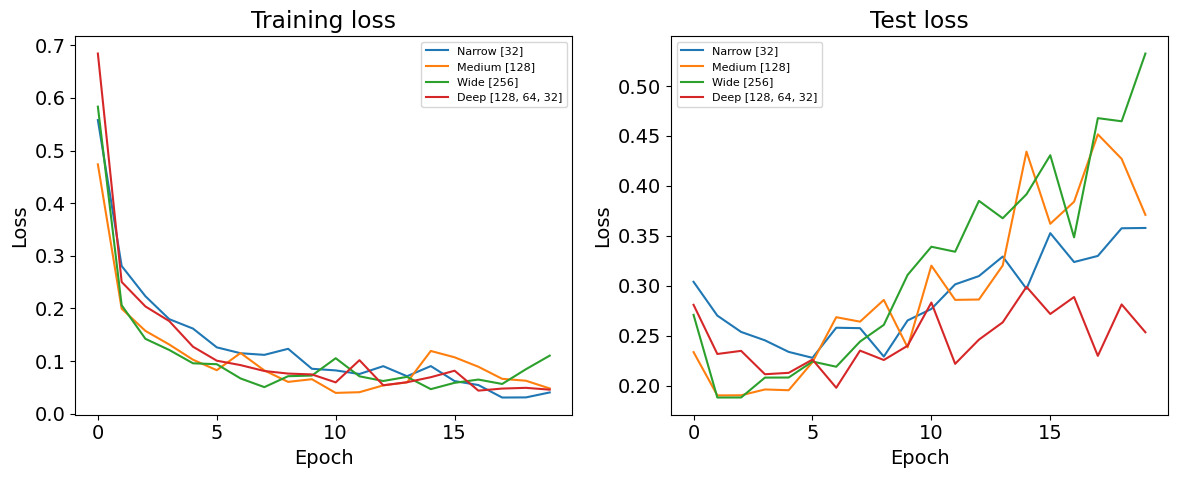

In [29]:
from torch.utils.data import DataLoader, Subset

# Subsampling
n_subsamples = 10000
indices = torch.randperm(len(mnist_train))[:n_subsamples] # Randomly select indices
mnist_train_sub = Subset(mnist_train, indices)
train_loader_sub = DataLoader(mnist_train_sub, batch_size=128, shuffle=True)
print(f"Subsampled training set size: {len(mnist_train_sub)}")

architectures = {
    'Narrow [32]': [32],
    'Medium [128]': [128],
    'Wide [256]': [256],
    'Deep [128, 64, 32]': [128, 64, 32],
}

results = {}

for name, hidden in architectures.items():
    print(f"\nTraining: {name}")
    torch.manual_seed(42)
    model = FlexNet(input_dim=28*28, hidden_sizes=hidden, num_classes=10, activation='relu').to(device)
    n_p = sum(p.numel() for p in model.parameters())
    
    tr_loss, te_loss = train_pytorch(
        model=model, 
        train_loader=train_loader_sub, # subsample
        test_loader=test_loader,
        lr=learning_rate,
        n_epochs=num_epochs, 
        verbose=False
    )
    
    results[name] = {
        'n_params': n_p, 'train_loss': tr_loss, 'test_loss': te_loss
    }

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name, r in results.items():
    axes[0].plot(r['train_loss'], lw=1.5, label=name)
    axes[1].plot(r['test_loss'], lw=1.5, label=name)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training loss'); axes[0].legend(fontsize=8)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Test loss'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


Deep NN has best performance.

Subsampled training set size: 500

Best test loss at epoch 8
After that, the network memorizes training data and generalizes worse.


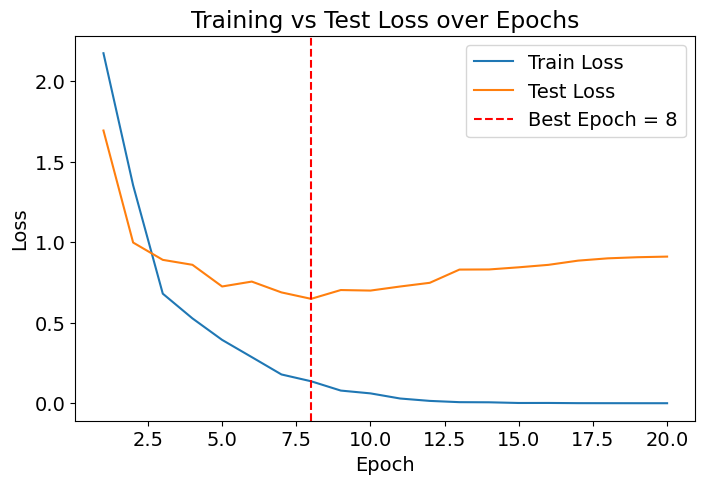

In [23]:
# Subsampling
n_subsamples = 500
indices = torch.randperm(len(mnist_train))[:n_subsamples] # Randomly select indices
mnist_train_sub = Subset(mnist_train, indices)
train_loader_sub = DataLoader(mnist_train_sub, batch_size=128, shuffle=True)
print(f"Subsampled training set size: {len(mnist_train_sub)}")

model = FlexNet(input_dim=28*28, hidden_sizes=[128,64,32], num_classes=10, activation='relu').to(device)
tr_loss, te_loss = train_pytorch(
        model=model, 
        train_loader=train_loader_sub, # subsample
        test_loader=test_loader,
        lr=0.01,
        n_epochs=20, 
        verbose=False
    )

epochs = range(1, len(tr_loss) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, tr_loss, label='Train Loss')
plt.plot(epochs, te_loss, label='Test Loss')

best_epoch = np.argmin(te_loss) + 1  # +1 to convert index → epoch number
plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch = {best_epoch}')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Test Loss over Epochs')
plt.legend()

print(f"\nBest test loss at epoch {best_epoch}")
print(f"After that, the network memorizes training data and generalizes worse.")


In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy

def train_with_early_stop(model, train_loader, test_loader, lr=0.001, n_epochs=20):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_loss = float('inf')
    best_epoch = 0
    best_model_wts = copy.deepcopy(model.state_dict())

    train_losses = []
    test_losses = []

    for epoch in range(n_epochs):
        # -------- TRAIN --------
        model.train()
        epoch_loss = 0.0
        n_batches = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            X_batch = X_batch.view(X_batch.size(0), -1)

            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        train_losses.append(epoch_loss / n_batches)

        # -------- VALIDATION (TEST) --------
        model.eval()
        test_loss_total = 0.0
        n_samples = 0
        correct = 0

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                X_batch = X_batch.view(X_batch.size(0), -1)

                y_pred = model(X_batch)
                batch_size = X_batch.size(0)

                test_loss_total += criterion(y_pred, y_batch).item() * batch_size
                n_samples += batch_size

                _, predicted = torch.max(y_pred, 1)
                correct += (predicted == y_batch).sum().item()

        test_loss = test_loss_total / n_samples
        test_acc = correct / n_samples

        test_losses.append(test_loss)

        # -------- EARLY STOPPING TRACK --------
        if test_loss < best_loss:
            best_loss = test_loss
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

    final_acc = test_acc  # from last epoch

    model.load_state_dict(best_model_wts)

    model.eval()
    correct = 0
    n_samples = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            X_batch = X_batch.view(X_batch.size(0), -1)

            y_pred = model(X_batch)
            _, predicted = torch.max(y_pred, 1)

            correct += (predicted == y_batch).sum().item()
            n_samples += X_batch.size(0)

    best_acc = correct / n_samples

    print(f"\nBest epoch (early stopping): {best_epoch}")
    print(f"Best test loss: {best_loss:.4f}")
    print(f"Accuracy (early-stopped model): {best_acc:.2%}")
    print(f"Accuracy (final model): {final_acc:.2%}")
    print(f"Useful epochs: {best_epoch} / {n_epochs}")

    return train_losses, test_losses, best_epoch, best_acc, final_acc

In [27]:
model = FlexNet(input_dim=28*28, hidden_sizes=[128], num_classes=10)

train_losses, test_losses, best_epoch, best_acc, final_acc = train_with_early_stop(
    model,
    train_loader,
    test_loader,
    lr=0.01,
    n_epochs=20
)


Best epoch (early stopping): 3
Best test loss: 0.1617
Accuracy (early-stopped model): 95.69%
Accuracy (final model): 95.86%
Useful epochs: 3 / 20


Accuracy differs with full training by ~1%, 3 epochs were actually useful.

In [33]:
model = FlexNet(input_dim=28*28, hidden_sizes=[32], num_classes=10)
tr_loss, te_loss = train_pytorch(
    model,
    train_loader,
    test_loader,
    lr=0.01,
    n_epochs=20,
    verbose=False
)


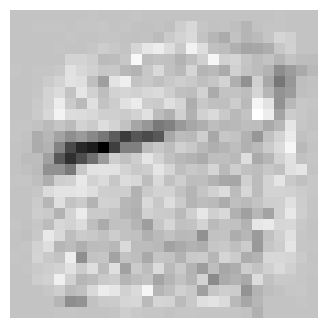

In [53]:
W1 = model.network[0].weight.data.cpu().numpy()
H = W1.shape[0]  # number of hidden units

plt.figure(figsize=(4, 4))  
plt.imshow(W1[12].reshape(28, 28), cmap='gray')
plt.axis('off')
plt.show()

In [55]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def visualize_misclassified(model, test_loader, num_samples=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    
    misclassified = []

    # -------- Collect misclassified samples --------
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            X_flat = X_batch.view(X_batch.size(0), -1)
            logits = model(X_flat)
            
            _, preds = torch.max(logits, 1)
            
            for i in range(len(y_batch)):
                if preds[i] != y_batch[i]:
                    misclassified.append((
                        X_batch[i].cpu(),
                        y_batch[i].cpu().item(),
                        preds[i].cpu().item(),
                        logits[i].cpu()
                    ))
                
                if len(misclassified) >= num_samples:
                    break
            if len(misclassified) >= num_samples:
                break

    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 3*num_samples))

    for i in range(num_samples):
        img, true_label, pred_label, logits = misclassified[i]
        
        probs = F.softmax(logits, dim=0).numpy()

        # --- Left: Image ---
        axes[i, 0].imshow(img.squeeze(), cmap='gray')
        axes[i, 0].set_title(f"True: {true_label} | Pred: {pred_label}")
        axes[i, 0].axis('off')

        # --- Right: Probability bar chart ---
        axes[i, 1].bar(range(10), probs)
        axes[i, 1].set_xticks(range(10))
        axes[i, 1].set_ylim(0, 1)
        axes[i, 1].set_title("Predicted probabilities")

    plt.tight_layout()
    plt.show()

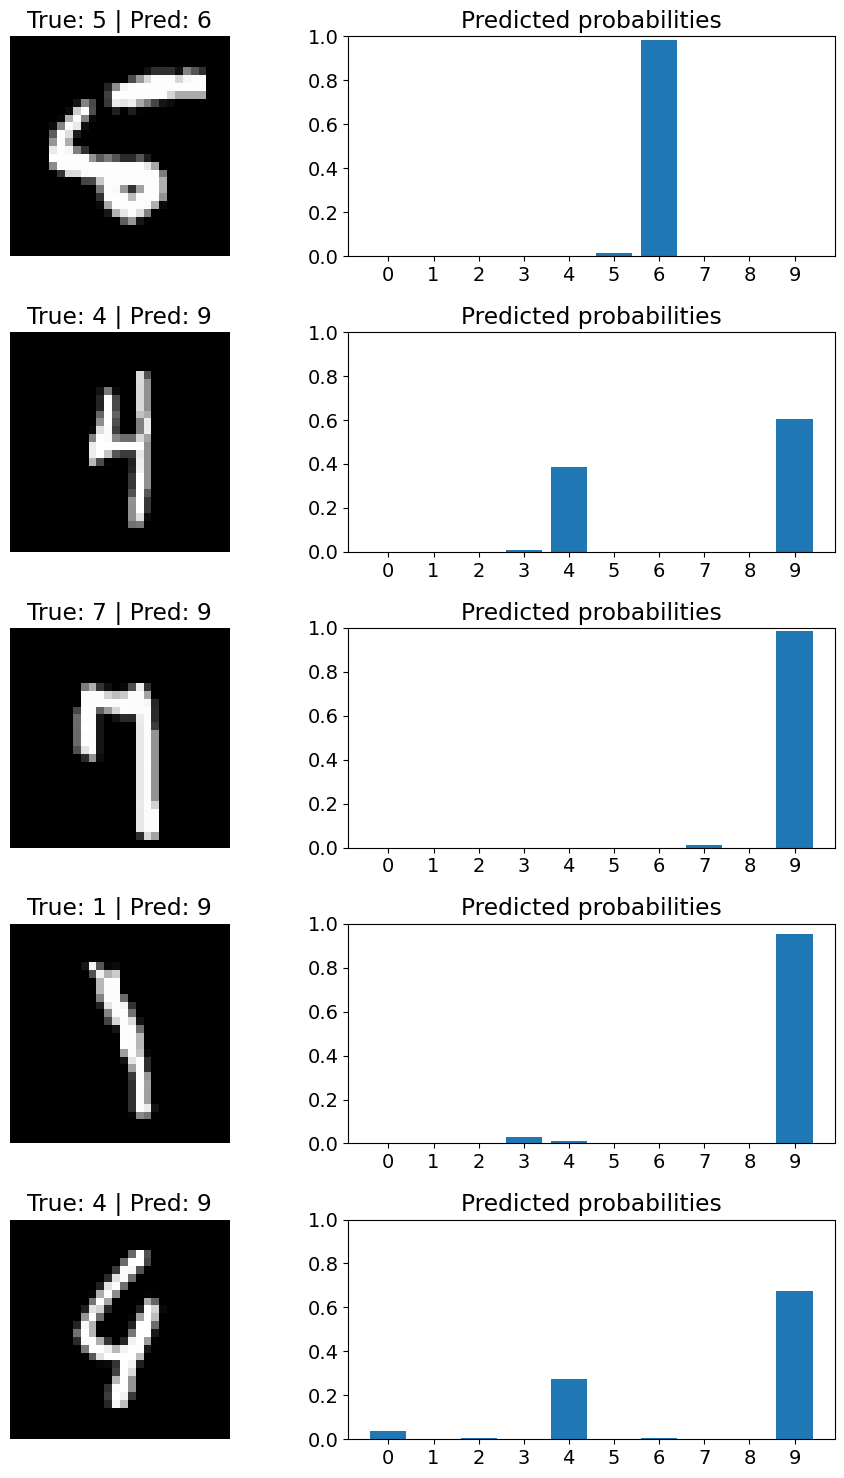

In [56]:
visualize_misclassified(model, test_loader, num_samples=5)